In [1]:
!pip install requests beautifulsoup4 pandas matplotlib

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [4]:
soup = BeautifulSoup(response.text, "html.parser")

In [5]:
books = soup.find_all("article", class_="product_pod")

print(len(books))

20


In [6]:
book = books[0]

title = book.h3.a["title"]

print(title)

A Light in the Attic


In [7]:
price = book.find("p", class_="price_color").text

print(price)

Â£51.77


In [8]:
availability = book.find("p", class_="instock availability").text.strip()

print(availability)

In stock


In [9]:
rating = book.find("p", class_="star-rating")["class"][1]

print(rating)

Three


In [10]:
link = book.h3.a["href"]

print(link)

catalogue/a-light-in-the-attic_1000/index.html


In [11]:
data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    availability = book.find(
        "p", class_="instock availability"
    ).text.strip()
    rating = book.find("p", class_="star-rating")["class"][1]
    link = book.h3.a["href"]

    data.append([
        title,
        price,
        availability,
        rating,
        link
    ])

In [12]:
df = pd.DataFrame(
    data,
    columns=[
        "Book Title",
        "Price",
        "Availability",
        "Rating",
        "Book URL"
    ]
)

df.head()

,Book Title,Price,Availability,Rating,Book URL
0,A Light in the Attic,Â£51.77,In stock,Three,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Â£53.74,In stock,One,catalogue/tipping-the-velvet_999/index.html
2,Soumission,Â£50.10,In stock,One,catalogue/soumission_998/index.html
3,Sharp Objects,Â£47.82,In stock,Four,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five,catalogue/sapiens-a-brief-history-of-humankind...


In [13]:
print(df.shape)

(20, 5)


In [14]:
print(df.columns)

Index(['Book Title', 'Price', 'Availability', 'Rating', 'Book URL'], dtype='object')


In [15]:
print(df.isnull().sum())

Book Title      0
Price           0
Availability    0
Rating          0
Book URL        0
dtype: int64


In [16]:
print(df.duplicated().sum())

0


In [18]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

C:\Users\alha\AppData\Local\Temp\ipykernel_14660\2424989057.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


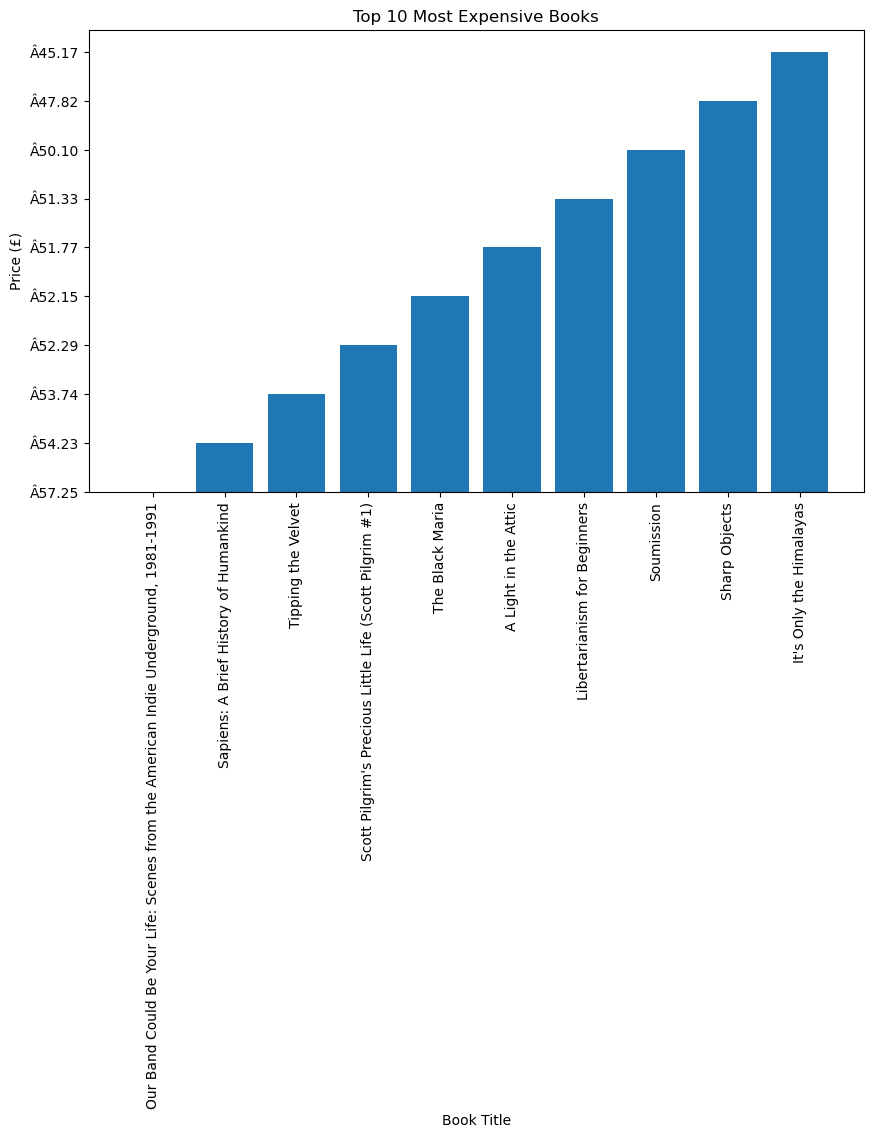

In [20]:
top_10 = df.sort_values(
    by="Price",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10["Book Title"],
    top_10["Price"]
)

plt.xticks(rotation=90)

plt.xlabel("Book Title")
plt.ylabel("Price (£)")
plt.title("Top 10 Most Expensive Books")

plt.tight_layout()

plt.show()

In [21]:
df.to_csv(
    "books_scraped_dataset.csv",
    index=False
)

In [22]:
df = pd.read_csv("books_scraped_dataset.csv")

print(df.head())

                              Book Title   Price Availability  Rating  \
0                   A Light in the Attic  Â51.77     In stock       3   
1                     Tipping the Velvet  Â53.74     In stock       1   
2                             Soumission  Â50.10     In stock       1   
3                          Sharp Objects  Â47.82     In stock       4   
4  Sapiens: A Brief History of Humankind  Â54.23     In stock       5   

                                            Book URL  
0     catalogue/a-light-in-the-attic_1000/index.html  
1        catalogue/tipping-the-velvet_999/index.html  
2                catalogue/soumission_998/index.html  
3             catalogue/sharp-objects_997/index.html  
4  catalogue/sapiens-a-brief-history-of-humankind...  


In [23]:
data = []

for page in range(1, 6):

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:

        title = book.h3.a["title"]

        price = book.find(
            "p",
            class_="price_color"
        ).text

        availability = book.find(
            "p",
            class_="instock availability"
        ).text.strip()

        rating = book.find(
            "p",
            class_="star-rating"
        )["class"][1]

        link = book.h3.a["href"]

        data.append([
            title,
            price,
            availability,
            rating,
            link
        ])

In [24]:
df = pd.DataFrame(
    data,
    columns=[
        "Book Title",
        "Price",
        "Availability",
        "Rating",
        "Book URL"
    ]
)

print(df.shape)

(100, 5)


In [26]:
df.to_csv(
    "books_web_scraped_dataset.csv",
    index=False
)